## L10

In [1]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
# Globalny motyw — raz, na początku notebooka
sns.set_theme(style='whitegrid', palette='muted')
# Dataset tips — restauracja, 244 rachunki (znany z W09)
tips = sns.load_dataset('tips')
print(f"Tips dataset: {tips.shape[0]} wierszy × {tips.shape[1]} kolumn")
print(f"Kolumny: {list(tips.columns)}")
tips.head(3)

Tips dataset: 244 wierszy × 7 kolumn
Kolumny: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


# Ćwiczenie 1: Statystyczne wykresy seaborn

Zadanie 1.1 — Barplot z hue

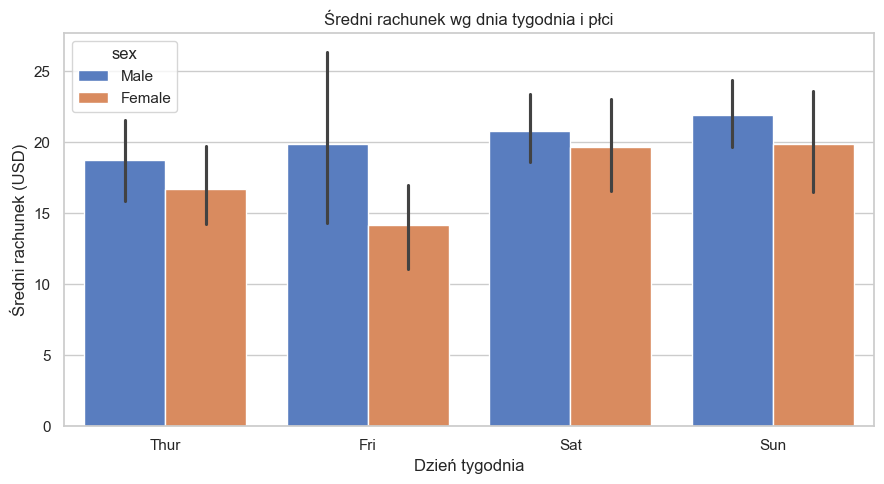

Zapisano: barplot_dzien_plec.png


In [2]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
data=tips,
x='day',
y='total_bill',
hue='sex',
ax=ax,
palette='muted',
errorbar=('ci', 95), # 95% CI = przedział ufności średniej
)
ax.set_title('Średni rachunek wg dnia tygodnia i płci')
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Średni rachunek (USD)')
plt.tight_layout()
plt.savefig('barplot_dzien_plec.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: barplot_dzien_plec.png")

Zadanie 1.2 — Boxplot

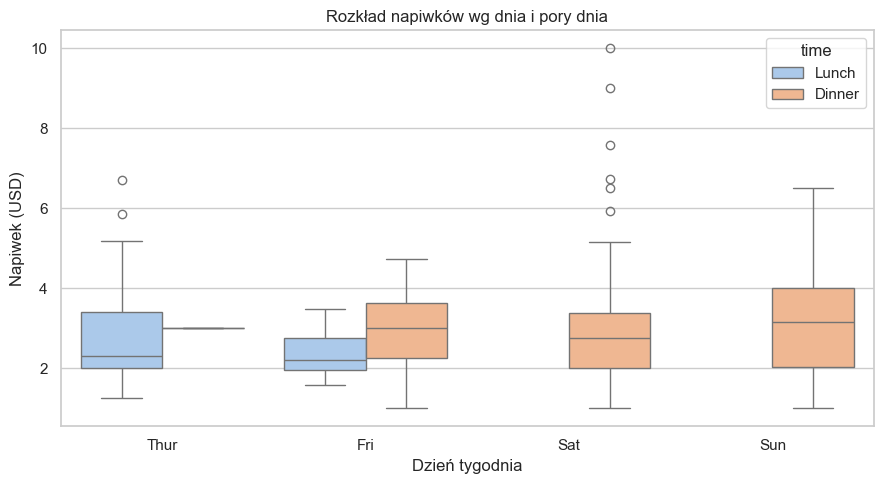

Zapisano: boxplot_napiwki.png


In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(
    data=tips,
    x="day",        
    y="tip",       
    hue="time",    
    ax=ax,
    palette='pastel',
)

ax.set_title('Rozkład napiwków wg dnia i pory dnia') 
ax.set_xlabel('Dzień tygodnia') 
ax.set_ylabel('Napiwek (USD)') 

plt.tight_layout() 
plt.savefig('boxplot_napiwki.png', dpi=150, bbox_inches='tight', facecolor='white') 
plt.show() 
plt.close() 
print("Zapisano: boxplot_napiwki.png") 

Zadanie 1.3 — Heatmap korelacji

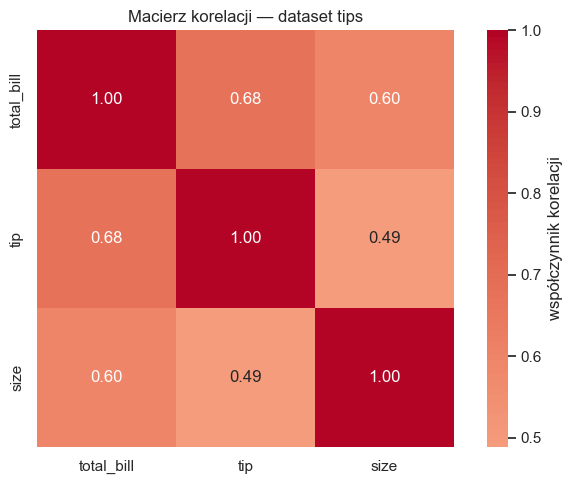

Zapisano: heatmap_korelacja.png


In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

corr = tips.select_dtypes('number').corr()

sns.heatmap(
    corr,
    annot=True,        
    fmt='.2f',          
    cmap='coolwarm',    
    center=0,          
    ax=ax,
    square=True,
    cbar_kws={'label': 'współczynnik korelacji'},
)

ax.set_title('Macierz korelacji — dataset tips')
plt.tight_layout()
plt.savefig('heatmap_korelacja.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: heatmap_korelacja.png")

Zadanie 1.4 — Scatter z hue + style

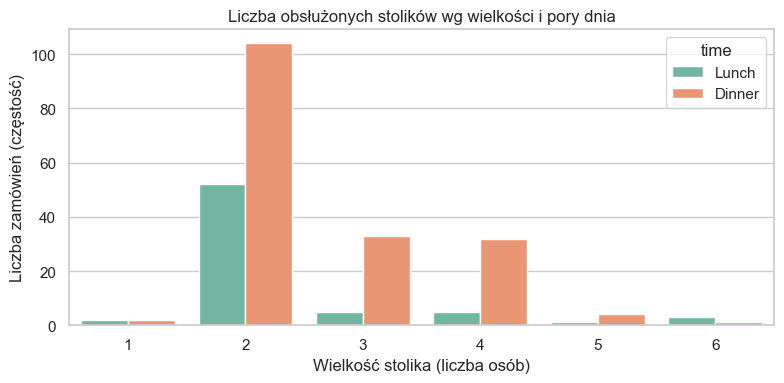

Zapisano: countplot_stoliki.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.countplot(
    data=tips,
    x="size",        
    hue="time",      
    ax=ax,
    palette="Set2"   
)

ax.set_title('Liczba obsłużonych stolików wg wielkości i pory dnia')
ax.set_xlabel('Wielkość stolika (liczba osób)')
ax.set_ylabel('Liczba zamówień (częstość)')

plt.tight_layout()
plt.savefig('countplot_stoliki.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: countplot_stoliki.png")

# Ćwiczenie 2: Subplots, GridSpec, shared axes

Zadanie 2.1 — Regularna siatka 2×2

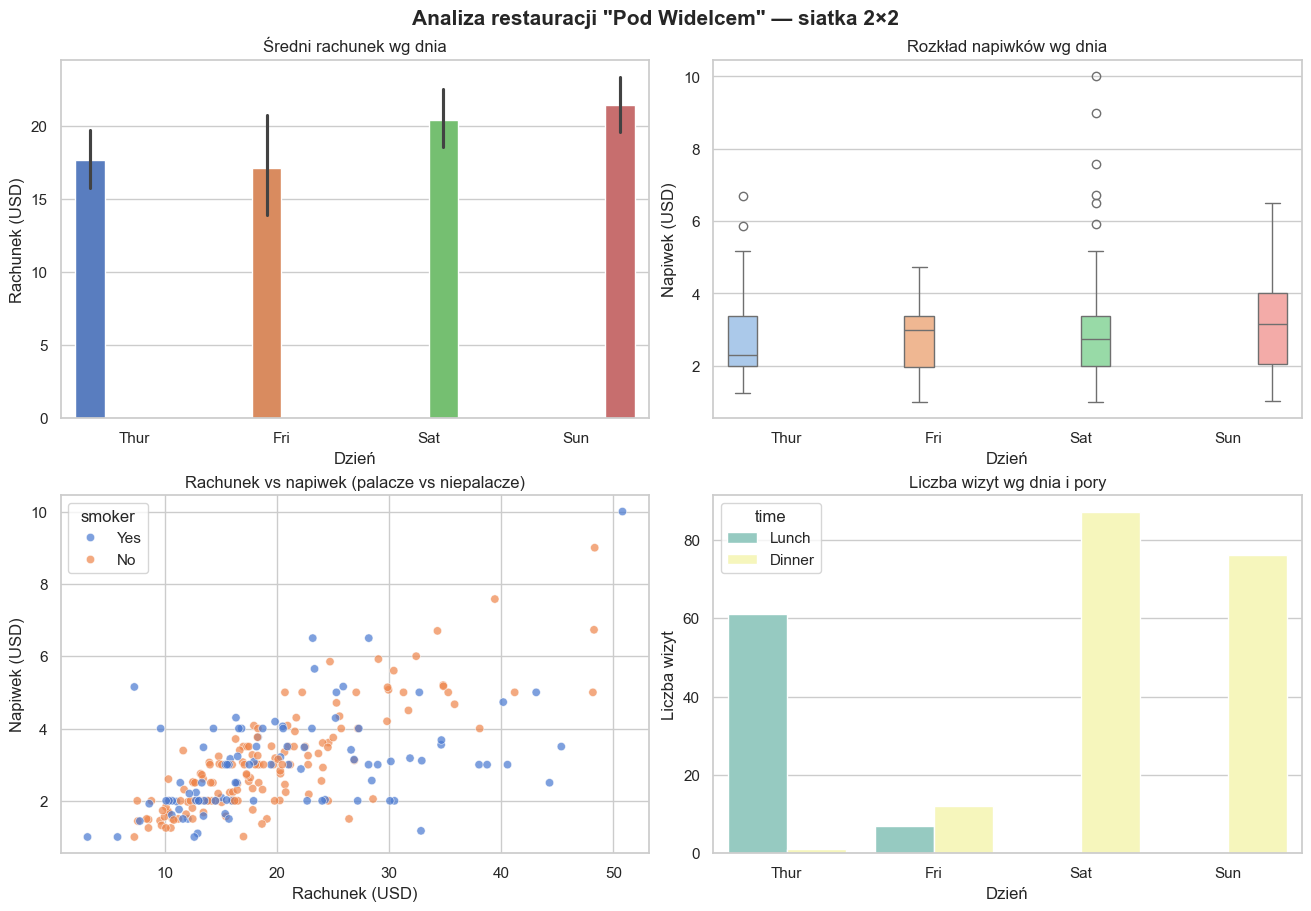

Zapisano: siatka_2x2.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

sns.barplot(
    data=tips, 
    x='day', 
    y='total_bill', 
    hue='day', 
    legend=False,
    ax=axes[0, 0], 
    palette='muted', 
    errorbar=('ci', 95)
) 
axes[0, 0].set_title('Średni rachunek wg dnia')
axes[0, 0].set_xlabel('Dzień')
axes[0, 0].set_ylabel('Rachunek (USD)')

sns.boxplot(
    data=tips,
    x='day',        
    y='tip',       
    hue='day', 
    legend=False,
    ax=axes[0, 1],
    palette='pastel',
)
axes[0, 1].set_title('Rozkład napiwków wg dnia')
axes[0, 1].set_xlabel('Dzień')
axes[0, 1].set_ylabel('Napiwek (USD)')

sns.scatterplot(
    data=tips,
    x='total_bill', 
    y='tip',        
    hue='smoker',
    alpha=0.7,
    ax=axes[1, 0],
)
axes[1, 0].set_title('Rachunek vs napiwek (palacze vs niepalacze)')
axes[1, 0].set_xlabel('Rachunek (USD)')
axes[1, 0].set_ylabel('Napiwek (USD)')

sns.countplot(
    data=tips,
    x='day',        
    hue='time',
    ax=axes[1, 1],
    palette='Set3',
)
axes[1, 1].set_title('Liczba wizyt wg dnia i pory')
axes[1, 1].set_xlabel('Dzień')
axes[1, 1].set_ylabel('Liczba wizyt')

fig.suptitle('Analiza restauracji "Pod Widelcem" — siatka 2×2', fontsize=15, fontweight='bold')
plt.savefig('siatka_2x2.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: siatka_2x2.png")

Zadanie 2.2 — GridSpec — nieregularny dashboard

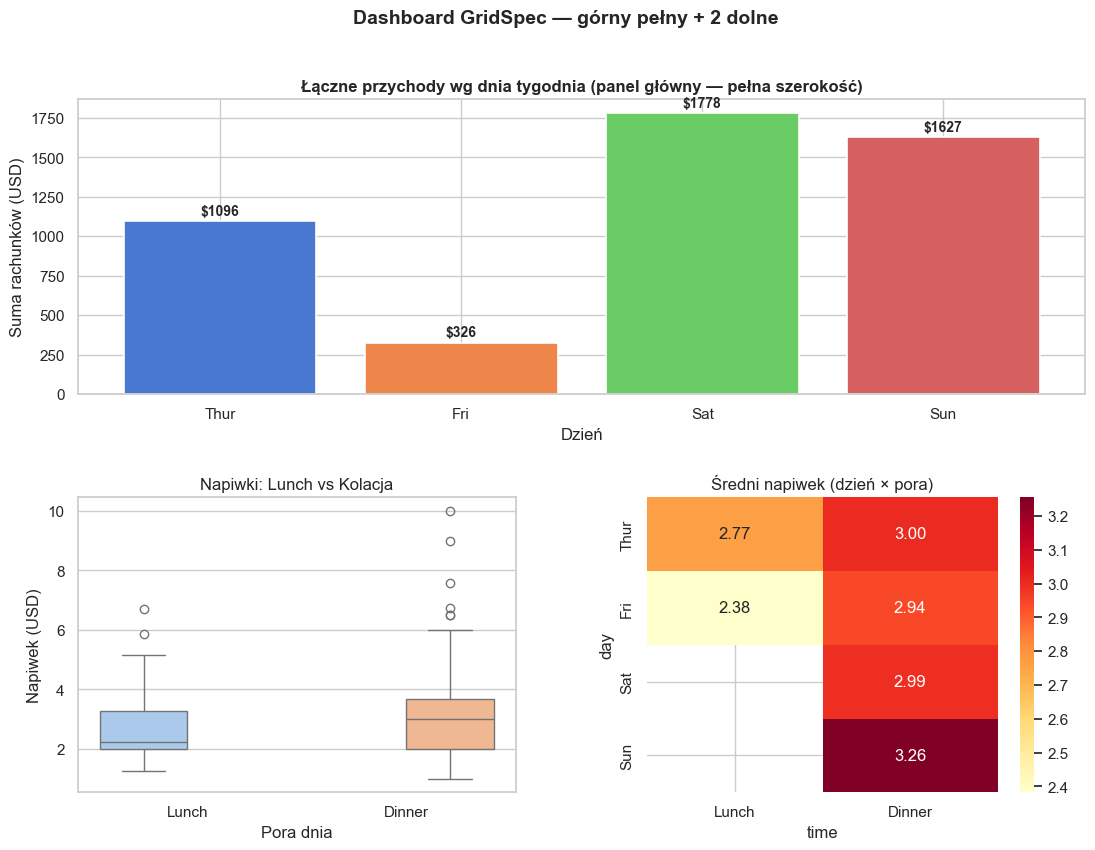

Zapisano: gridspec_dashboard.png


In [8]:

sns.set_theme(style='whitegrid', palette='muted')

tips = sns.load_dataset('tips')

fig = plt.figure(figsize=(13, 9))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

ax_top = fig.add_subplot(gs[0, :])

tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()

ax_top.bar(
    tips_sum['day'].astype(str),
    tips_sum['total_bill'],
    color=sns.color_palette('muted')[:4],
    edgecolor='white',
    linewidth=1.2,
)

for i, val in enumerate(tips_sum['total_bill']):
    ax_top.text(i, val + 20, f'${val:.0f}',
                ha='center', va='bottom',
                fontsize=10, fontweight='bold')

ax_top.set_title(
    'Łączne przychody wg dnia tygodnia (panel główny — pełna szerokość)',
    fontsize=12, fontweight='bold'
)
ax_top.set_xlabel('Dzień')
ax_top.set_ylabel('Suma rachunków (USD)')

ax_bl = fig.add_subplot(gs[1, 0])

sns.boxplot(
    data=tips,
    x='time',
    y='tip',
    hue='time', legend=False,
    ax=ax_bl,
    palette='pastel',
)

ax_bl.set_title('Napiwki: Lunch vs Kolacja')
ax_bl.set_xlabel('Pora dnia')
ax_bl.set_ylabel('Napiwek (USD)')

ax_br = fig.add_subplot(gs[1, 1])

pivot = tips.pivot_table(
    values='tip',
    index='day',
    columns='time',
    aggfunc='mean',
    observed=True
)

sns.heatmap(
    pivot,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    ax=ax_br
)

ax_br.set_title('Średni napiwek (dzień × pora)')

fig.suptitle(
    'Dashboard GridSpec — górny pełny + 2 dolne',
    fontsize=14,
    fontweight='bold'
)

plt.savefig(
    'gridspec_dashboard.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()
plt.close()

print("Zapisano: gridspec_dashboard.png")

Zadanie 2.3 — Shared axes

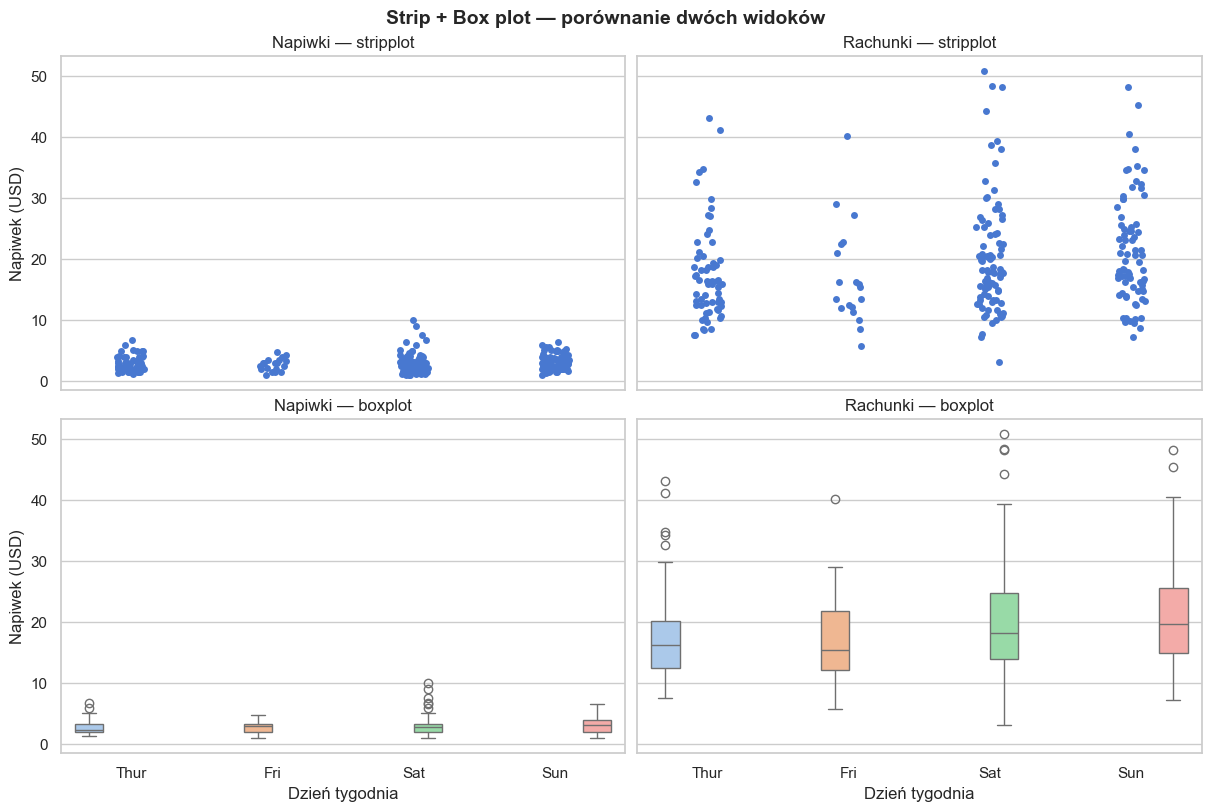

Zapisano: shared_axes.png


In [9]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8),
    sharex='col',
    sharey='row',
    constrained_layout=True
)

sns.stripplot(
    data=tips,
    x='day',
    y='tip',
    jitter=True,
    ax=axes[0, 0]
)
axes[0, 0].set_title('Napiwki — stripplot')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Napiwek (USD)')

sns.boxplot(
    data=tips,
    x='day',
    y='tip',
    hue='day', legend=False,
    ax=axes[1, 0],
    palette='pastel'
)
axes[1, 0].set_title('Napiwki — boxplot')
axes[1, 0].set_xlabel('Dzień tygodnia')
axes[1, 0].set_ylabel('Napiwek (USD)')

sns.stripplot(
    data=tips,
    x='day',
    y='total_bill',
    jitter=True,
    ax=axes[0, 1]
)
axes[0, 1].set_title('Rachunki — stripplot')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Rachunek (USD)')

sns.boxplot(
    data=tips,
    x='day',
    y='total_bill',
    hue='day', legend=False,
    ax=axes[1, 1],
    palette='pastel'
)
axes[1, 1].set_title('Rachunki — boxplot')
axes[1, 1].set_xlabel('Dzień tygodnia')
axes[1, 1].set_ylabel('Rachunek (USD)')

fig.suptitle(
    'Strip + Box plot — porównanie dwóch widoków',
    fontsize=14,
    fontweight='bold'
)

plt.savefig(
    'shared_axes.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()
plt.close()

print("Zapisano: shared_axes.png")

## Ćwiczenie 3: Pełny dashboard analityczny

Zadanie 3.1 — Projekt dashboardu

Pytanie główne (KPI):
W którym dniu restauracja osiąga największe przychody?
wykres: barplot (suma rachunków per dzień), duży panel na górze.

Panele pomocnicze:
countplot — liczba wizyt wg dnia i pory dnia
boxplot — rozkład napiwków wg dnia
heatmap — korelacje między zmiennymi (total_bill, tip, size)
scatterplot — zależność rachunek vs napiwek (z podziałem na smoker)

Panel sumaryczny:
violinplot — rozkład rachunków wg dnia i pory dnia

Układ:
GridSpec 3×3:
górny panel (KPI) zajmuje większość szerokości
środkowy rząd: 3 mniejsze wykresy
dolny panel: szeroki wykres podsumowujący

Zadanie 3.2 — Implementacja dashboardu

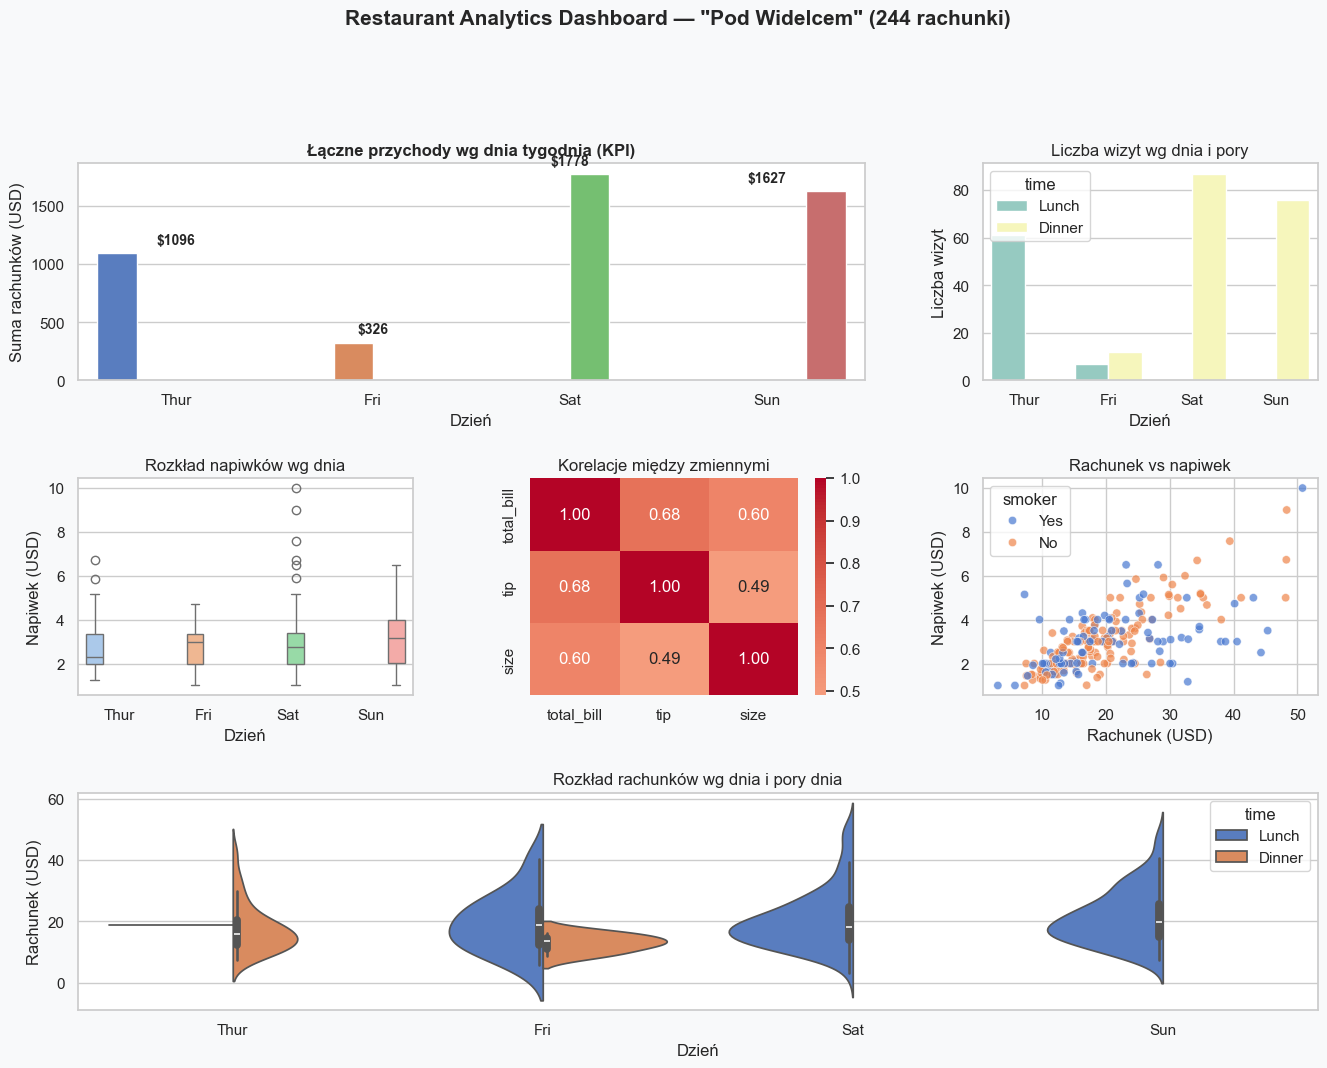

Zapisano: dashboard_pod_widelcem.png


In [10]:
# === FIGURA ===
fig = plt.figure(figsize=(16, 11))
fig.patch.set_facecolor('#f8f9fa')

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# === PANEL 1 (KPI) — przychody ===
ax1 = fig.add_subplot(gs[0, :2])

tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()

sns.barplot(
    data=tips_sum,
    x='day',
    y='total_bill',
    hue='day',
    legend=False,
    ax=ax1,
    palette='muted'
)
for i, val in enumerate(tips_sum['total_bill']):
    ax1.text(i, val + 50, f'${val:.0f}',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

ax1.set_title('Łączne przychody wg dnia tygodnia (KPI)', fontweight='bold')
ax1.set_xlabel('Dzień')
ax1.set_ylabel('Suma rachunków (USD)')

# === PANEL 2 — liczba wizyt ===
ax2 = fig.add_subplot(gs[0, 2])

sns.countplot(
    data=tips,
    x='day',
    hue='time',
    ax=ax2,
    palette='Set3'
)

ax2.set_title('Liczba wizyt wg dnia i pory')
ax2.set_xlabel('Dzień')
ax2.set_ylabel('Liczba wizyt')

# === PANEL 3 — boxplot napiwków ===
ax3 = fig.add_subplot(gs[1, 0])

sns.boxplot(
    data=tips,
    x='day',
    y='tip',
    hue='day',
    legend=False,
    ax=ax3,
    palette='pastel'
)

ax3.set_title('Rozkład napiwków wg dnia')
ax3.set_xlabel('Dzień')
ax3.set_ylabel('Napiwek (USD)')

# === PANEL 4 — heatmap korelacji ===
ax4 = fig.add_subplot(gs[1, 1])

corr = tips.select_dtypes('number').corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax4
)

ax4.set_title('Korelacje między zmiennymi')

# === PANEL 5 — scatter ===
ax5 = fig.add_subplot(gs[1, 2])

sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='smoker',
    alpha=0.7,
    ax=ax5
)

ax5.set_title('Rachunek vs napiwek')
ax5.set_xlabel('Rachunek (USD)')
ax5.set_ylabel('Napiwek (USD)')

# === PANEL 6 — violinplot ===
ax6 = fig.add_subplot(gs[2, :])

sns.violinplot(
    data=tips,
    x='day',
    y='total_bill',
    hue='time',
    split=True,
    ax=ax6
)

ax6.set_title('Rozkład rachunków wg dnia i pory dnia')
ax6.set_xlabel('Dzień')
ax6.set_ylabel('Rachunek (USD)')

# === TYTUŁ ===
fig.suptitle(
    'Restaurant Analytics Dashboard — "Pod Widelcem" (244 rachunki)',
    fontsize=15,
    fontweight='bold',
    y=1.02
)

plt.savefig(
    'dashboard_pod_widelcem.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()
plt.close()

print("Zapisano: dashboard_pod_widelcem.png")

Zadanie 3.3 — Wnioski biznesowe

Największe przychody restauracja osiąga w sobotę, co wynika z najwyższej sumy rachunków w tym dniu.
Istnieje wyraźna dodatnia korelacja między wartością rachunku a napiwkiem — im wyższy rachunek, tym większy napiwek.
Nie widać dużych różnic w napiwkach między palaczami a niepalaczami, choć mogą występować niewielkie odchylenia.
Na podstawie dashboardu można zalecić właścicielowi skupienie się na weekendach (szczególnie sobocie), np. poprzez zwiększenie obsady lub promocje, aby maksymalizować przychody.

## Ćwiczenie 4: Style, eksport, adnotacja, commit

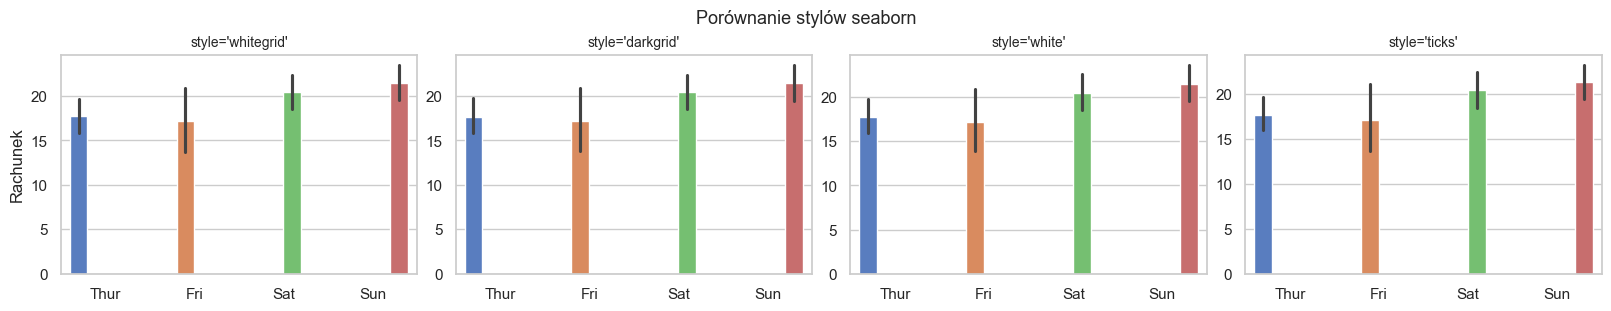

In [12]:


styles = ['whitegrid', 'darkgrid', 'white', 'ticks']

fig, axes = plt.subplots(1, 4, figsize=(16, 3), constrained_layout=True)

for ax, style in zip(axes, styles):
    with sns.axes_style(style):
        sns.barplot(
            data=tips,
            x='day',
            y='total_bill',
            hue='day',
            legend=False,
            ax=ax,
            palette='muted'
        )
        ax.set_title(f"style='{style}'", fontsize=10)
        ax.set_xlabel('')
        ax.set_ylabel('Rachunek' if ax is axes[0] else '')

fig.suptitle('Porównanie stylów seaborn', fontsize=13)

plt.savefig(
    'porownanie_stylow.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()
plt.close()

Styl whitegrid lub darkgrid jest odpowiedni do prezentacji zarządczych, ponieważ siatka ułatwia odczyt wartości.
Styl white jest odpowiedni do publikacji naukowych, ponieważ jest minimalistyczny i bardziej profesjonalny.

Zadanie 4.2 — Adnotacja na wykresie

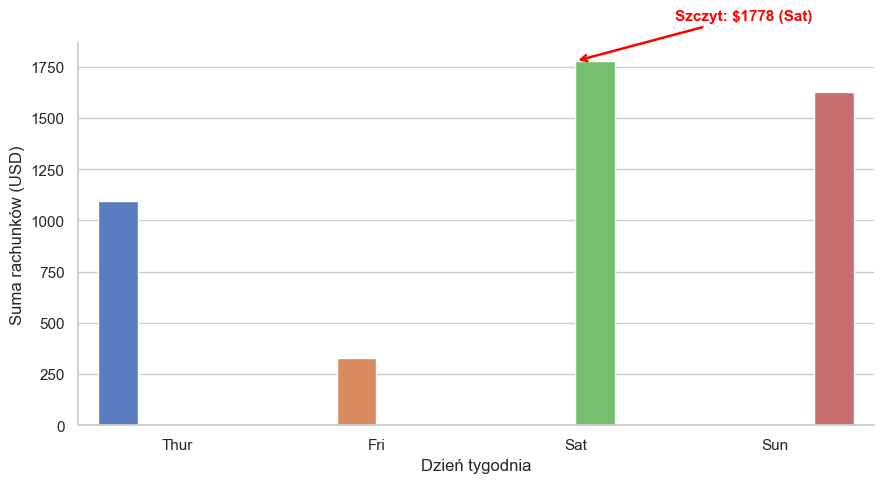

Zapisano: szczyt_przychodow.png


In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()

sns.barplot(
    data=tips_sum,
    x='day',
    y='total_bill',
    hue='day',
    legend=False,
    ax=ax,
    palette='muted'
)

# Znajdź maksimum
max_idx = tips_sum['total_bill'].idxmax()
max_day = tips_sum.loc[max_idx, 'day']
max_val = tips_sum.loc[max_idx, 'total_bill']

# Adnotacja
ax.annotate(
    f'Szczyt: ${max_val:.0f} ({max_day})',
    xy=(max_idx, max_val),            
    xytext=(max_idx + 0.5, max_val + 200), 
    arrowprops=dict(arrowstyle='->', color='red', lw=1.8),
    fontsize=11,
    color='red',
    fontweight='bold'
)

ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Suma rachunków (USD)')

sns.despine()

plt.tight_layout()

plt.savefig(
    'szczyt_przychodow.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()
plt.close()

print("Zapisano: szczyt_przychodow.png")